# Cuts and tags

* N molecules are cut with the same breakpoints

* Each molecule is labeled with a tag with M possible values. The frequencies of the tags is not uniform: $p_1, ..., p_M$

* How many unique tags do we expect to see?

* The probability of missing the i-th tag is $(1-p_i)^N$.

* Then, the probability to see the i-th tag is $1-(1-p_i)^N$.

* The expected number of unique tags observed is 

$$\sum_{i=1}^M 1 - (1-p_i)^N = M-\sum_{i=1}^M (1-p_i)^N = \psi(N)$$

* Given an expectation of unique tags and a vector of probabilities, we want to find $N = \psi^{-1}(e)$.

* The proportion of repeated tags is 

$$\rho(e) = \frac{N - e}{N}$$

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import brentq

import matplotlib.pyplot as plt

In [2]:
def func(N, p):
    """
    p: numpy array of probabilities
    N: number of independent trials
    """
    return np.sum(1 - (1 - p) ** N)


def find_N(p, target):
    """
    p: numpy array of probabilities
    target: target value for the sum
    """
    # Define a function that we want to find the root of
    def objective(N):
        return func(N, p) - target
    
    # Use brentq to find the root of the objective function
    N_solution = brentq(objective, 1, 1e6)  # Search for N in the range [1, 1e6]
    
    return N_solution

In [3]:
# Example usage

k = 1024
p = np.ones(k) / k  # Uniform probabilities
target = 500  # Target value
N_solution = find_N(p, target)
print(f"Estimated N: {N_solution}")
print(f"Estimated proportion of repeats: {(N_solution - target) / N_solution:.4f}")

Estimated N: 685.7245995786925
Estimated proportion of repeats: 0.2708


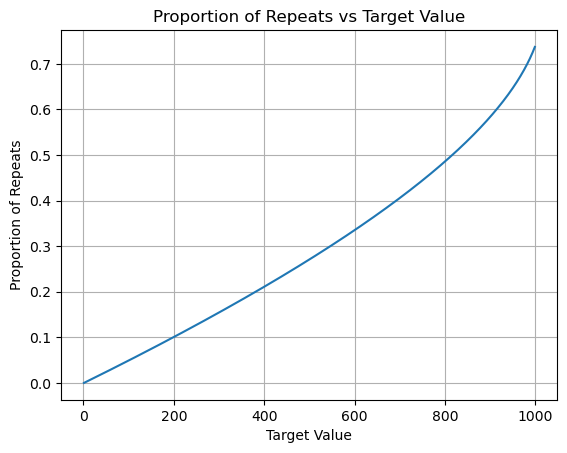

In [4]:
# Plotting the proportion of repeats for a range of target values

targets = np.arange(1, 1000)
N_solutions = [find_N(p, target) for target in targets]
proportions_repeats = [(N - target) / N for N, target in zip(N_solutions, targets)]
plt.plot(targets, proportions_repeats)
plt.xlabel('Target Value')
plt.ylabel('Proportion of Repeats')
plt.title('Proportion of Repeats vs Target Value')
plt.grid()
plt.show()

In [5]:
# Extreme case: when target is small

k = 1024
p = np.ones(k) / k  # Uniform probabilities
target = 2  # Target value
N_solution = find_N(p, target)
print(f"Estimated N: {N_solution}")
print(f"Estimated proportion of repeats: {(N_solution - target) / N_solution:.4f}")

Estimated N: 2.000977995265819
Estimated proportion of repeats: 0.0005


In [9]:
# Extreme case: when target is small

k = 1024
p = np.random.dirichlet(0.75 * np.ones(k))  # Uniform probabilities
target = 1  # Target value
N_solution = find_N(p, target)
print(f"Estimated N: {N_solution}")
print(f"Estimated proportion of repeats: {(N_solution - target) / N_solution:.4f}")

Estimated N: 1.0
Estimated proportion of repeats: 0.0000


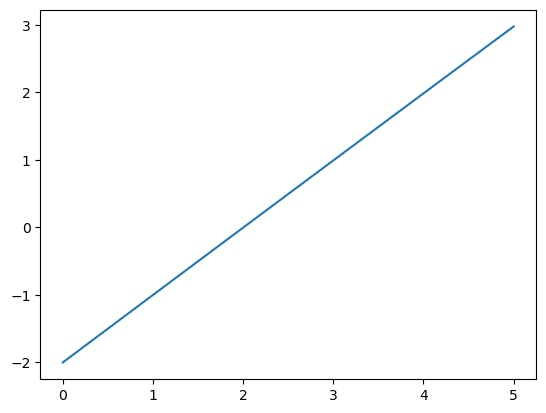

In [10]:
x = np.linspace(0, 5, num=100)
y = [func(N, p) - 2 for N in x]

plt.plot(x, y)
plt.show()

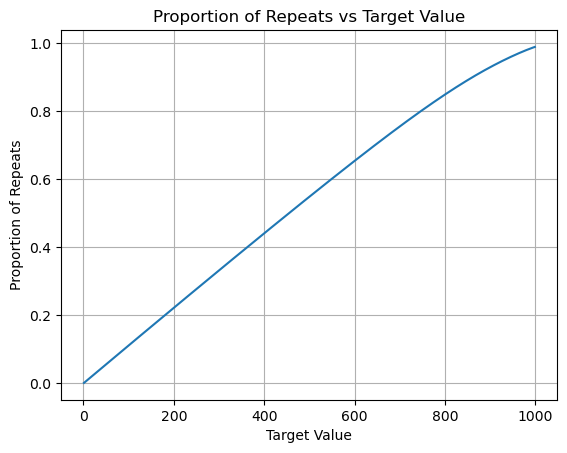

In [11]:
# Plotting the proportion of repeats for a range of target values

targets = np.arange(1, 1000)
N_solutions = [find_N(p, target) for target in targets]
proportions_repeats = [(N - target) / N for N, target in zip(N_solutions, targets)]
plt.plot(targets, proportions_repeats)
plt.xlabel('Target Value')
plt.ylabel('Proportion of Repeats')
plt.title('Proportion of Repeats vs Target Value')
plt.grid()
plt.show()

# Posterior expectation of N given observed repeats N' = 1

The inversion problem for N'=1 gives N=1, i.e. the solution collapses for N'=1, which is clearly not correct.

Because N'=1 is an important case, given how frequently we encounter this case, it is worth a careful analysis.

Assuming a flat prior for the probability of N, we want to compute the posterior expectation

$$E(N|N'=1)=\sum_{N=1}^\infty N\cdot P(N|N'=1)$$

Let's first unpack the probability:

$$P(N|N'=1) = \frac{P(N'=1|N)\cdot P(N)}{\sum_{n=1}^\infty P(N'=1|n)\cdot P(n)} = \frac{P(N'=1|N)}{\sum_{n=1}^\infty P(N'=1|n)} 
= \frac{\sum_i p_i^N}{\sum_{n=1}^\infty\sum_i p_i^n} = \frac{\sum_i p_i^N}{\sum_i \frac{p_i}{1-p_i}}$$

where we are using the flat prior and the fact that the infinite series $\sum_{n=1}^\infty x^n$ converges to $\frac{x}{1-x}$ for $0\leq x < 1$

Plugging this expression in the posterior expectation expression and using the fact that the infinite series $\sum_{n=1}^\infty nx^n$ 
converges to $\frac{x}{(1-x)^2}$ for $0\leq x < 1$, we obtain the following:

$$E(N|N'=1) = \frac{\sum_i \frac{p_i}{(1-p_i)^2}}{\sum_i \frac{p_i}{1-p_i}}$$

In [27]:

def posterior_expectation_one_repeat(p):
    """
    p: numpy array of probabilities
    """
    num = np.sum(p / ((1 - p)**2))
    den = np.sum(p / (1 - p))
    return num / den

expected_N = posterior_expectation_one_repeat(p)
expected_N

1.0022384228284476